In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve,
    recall_score, precision_score, f1_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import json

In [3]:
df = pd.read_csv("data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# 3. Tiền xử lý cơ bản + chia dữ liệu

# Thay giá trị 0 bằng nan
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
df[cols_with_zero] = df[cols_with_zero].fillna(df[cols_with_zero].median())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (614, 8) Test: (154, 8)


In [5]:
# 4. Xây pipeline (Scaler + SMOTE + XGBoost)

pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.005,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        scale_pos_weight=1,
        eval_metric='aucpr'
    ))
])

In [6]:
# 5. Stratified K-Fold Cross Validation

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recalls, precisions, f1s = [], [], []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_val)

    recalls.append(recall_score(y_val, y_pred))
    precisions.append(precision_score(y_val, y_pred))
    f1s.append(f1_score(y_val, y_pred))

    print(f"Fold {fold}: Recall = {recall_score(y_val, y_pred):.3f}, Precision = {precision_score(y_val, y_pred):.3f}, F1 = {f1_score(y_val, y_pred):.3f}")

print(f"\nRecall trung bình = {np.mean(recalls):.3f}, Precision trung bình = {np.mean(precisions):.3f}, F1 = {np.mean(f1s):.3f}")

Fold 1: Recall = 0.791, Precision = 0.680, F1 = 0.731
Fold 2: Recall = 0.721, Precision = 0.596, F1 = 0.653
Fold 3: Recall = 0.698, Precision = 0.667, F1 = 0.682
Fold 4: Recall = 0.767, Precision = 0.635, F1 = 0.695
Fold 5: Recall = 0.738, Precision = 0.633, F1 = 0.681

Recall trung bình = 0.743, Precision trung bình = 0.642, F1 = 0.688


In [7]:
# 6. Huấn luyện

pipeline.fit(X_train, y_train)
proba = pipeline.predict_proba(X_test)[:, 1]

prec, rec, thr = precision_recall_curve(y_test, proba)
target_recall = 0.8
# Tìm threshold có recall gần nhất 0.8
idx = (np.abs(rec[:-1] - target_recall)).argmin()
best_threshold = thr[idx]

print(f"Threshold: {best_threshold:.3f}")


Threshold: 0.537


Classification report:
               precision    recall  f1-score   support

           0       0.87      0.75      0.81       100
           1       0.63      0.80      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.79      0.77      0.77       154

ROC-AUC: 0.822


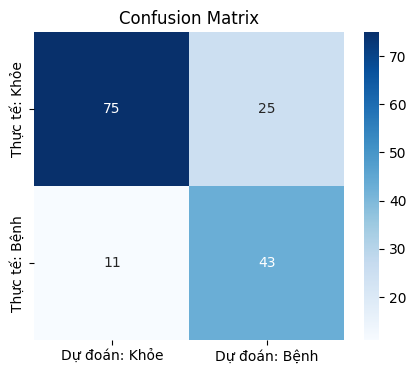

In [8]:
# 7. Đánh giá mô hình trên test set

y_pred_custom = (proba >= best_threshold).astype(int)

print("Classification report:\n", classification_report(y_test, y_pred_custom))

print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}")

cm = confusion_matrix(y_test, y_pred_custom)

# Tạo DataFrame với label tiếng Việt
cm_df = pd.DataFrame(
    cm,
    index=['Thực tế: Khỏe', 'Thực tế: Bệnh'],
    columns=['Dự đoán: Khỏe', 'Dự đoán: Bệnh']
)

# Vẽ heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


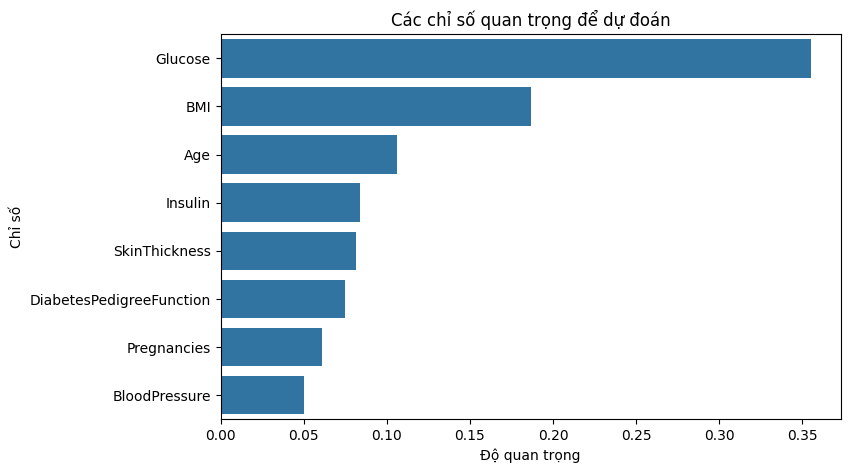

In [9]:
# 9. Feature Importance
final_model = pipeline.named_steps['model']

importance = pd.DataFrame({
    'Chỉ số': X.columns,
    'Độ quan trọng': final_model.feature_importances_
}).sort_values(by='Độ quan trọng', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Độ quan trọng', y='Chỉ số', data=importance)
plt.title("Các chỉ số quan trọng để dự đoán")
plt.show()


In [12]:
model_path = "artifacts/diabetes_xgboost_pipeline.pkl"
joblib.dump(pipeline, model_path)

schema = {
    "features": list(X.columns),
    "target": "Outcome"
}
schema_path = "artifacts/diabetes_xgboost_schema.json"
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=4, ensure_ascii=False)

threshold_path = "artifacts/diabetes_xgboost_threshold.json"
with open(threshold_path, "w", encoding="utf-8") as f:
    json.dump({"best_threshold": float(best_threshold), "target_recall": 0.8}, f, indent=4)